# 5.0 Data Processing V2 (Corrected & Enhanced)

## Objectives
1.  **Data Ingestion & Mapping (Fixed)**: Robust ICD-9/ICD-10 mapping for condition flags.
2.  **Feature Engineering (Restored)**: 
    *   **Inflation Adjustment**: Convert costs to 2025 baseline.
    *   **Jumpers & Risers**: Identify patients with escalating risk.
    *   **Care Phenotypes**: Clustering based on Utilization (moved after FE).
3.  **Target Definition**: 3-Tier Risk Model.


## Data Requirements


All longitudinal files have complete `TOTEXPY1` and `TOTEXPY2` expense data.

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# --- CONFIGURATION ---
# Use newly parsed data in data/processed_v2 (has Panels 18-21 complete with TOTEXPY1/Y2)
DATA_DIR = Path('../data/processed_v2')
# Fallback to archive for files not yet re-parsed
DATA_DIR_ARCHIVE = Path('../archive_v1/data/processed')
DATA_DIR_NEW = DATA_DIR  # Alias for compatibility
OUTPUT_DIR = Path('../data/processed_v2')
REPORT_DIR = Path('../reports')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'figures').mkdir(exist_ok=True)
(REPORT_DIR / 'tables').mkdir(exist_ok=True)

# Medical CPI Factors (Base 2025)
CPI_FACTORS = {
    2013: 1.45, 2014: 1.41, 2015: 1.37,
    2016: 1.32, 2017: 1.28, 2018: 1.24,
    2019: 1.20, 2020: 1.18
}

# Panel Mapping - IMPORTANT: Panels 22+ have different data structure
# Panels 18-21: Longitudinal files contain BOTH Y1 and Y2 expense data (TOTEXPY1, TOTEXPY2)
# Panels 22+: Longitudinal files only have Y2 data, need Full Year Consolidated for Y1
#
# To use Panel 22: Download HC-201 (2017 Full Year), save as h201.parquet
# To use Panel 23: Download HC-216 (2018 Full Year), save as h216.parquet
#
PANEL_MAP = [
    # All panels now have complete TOTEXPY1 and TOTEXPY2 data
    {'panel': 18, 'long': 'h172', 'cond_y1': 'h162', 'meds_y1': 'h160a', 'year1': 2013, 'naming': 'Y1Y2'},
    {'panel': 19, 'long': 'h183', 'cond_y1': 'h170', 'meds_y1': 'h168a', 'year1': 2014, 'naming': 'Y1Y2'},
    {'panel': 20, 'long': 'h193', 'cond_y1': 'h180', 'meds_y1': 'h178a', 'year1': 2015, 'naming': 'Y1Y2'},
    {'panel': 21, 'long': 'h202', 'cond_y1': 'h190', 'meds_y1': 'h188a', 'year1': 2016, 'naming': 'Y1Y2'},
    {'panel': 22, 'long': 'h210', 'cond_y1': 'h199', 'meds_y1': 'h197a', 'year1': 2017, 'naming': 'Y1Y2'},
    {'panel': 23, 'long': 'h217', 'cond_y1': 'h207', 'meds_y1': 'h206a', 'year1': 2018, 'naming': 'Y1Y2'},
]

ILL_DEFINED_CCS_ICD9 = [str(i) for i in range(245, 260)]

print(f"Setup Complete. Reading from {DATA_DIR}")
print(f"Panels: {[p['panel'] for p in PANEL_MAP]}")

Setup Complete. Reading from ../data/processed_v2
Panels: [18, 19, 20, 21, 22, 23]


In [89]:
def process_panel(pmap):
    """
    Process a single MEPS panel: Load longitudinal data and merge with Conditions/Meds.
    Handles both old (Y1/Y2) and new (year suffix) naming conventions.
    """
    panel = pmap['panel']
    year1 = pmap['year1']
    year2 = year1 + 1
    naming = pmap.get('naming', 'Y1Y2')
    
    print(f"Processing Panel {panel} ({year1}-{year2})...", end=" ")
    
    # 1. Load Longitudinal File (check both directories)
    f_long = DATA_DIR / f"{pmap['long']}.parquet"
    if not f_long.exists():
        f_long = DATA_DIR_ARCHIVE / f"{pmap['long']}.parquet"
    if not f_long.exists():
        print(f"SKIP - {pmap['long']}.parquet not found")
        return None
    df_long = pd.read_parquet(f_long)
    
    # 2. For Panels 22+, check if we need Full Year file for Y1 data
    if naming == 'YEAR' and 'fullyear_y1' in pmap:
        # Check both DATA_DIR and DATA_DIR_NEW for the full year file
        f_fy = DATA_DIR / f"{pmap['fullyear_y1']}.parquet"
        if not f_fy.exists():
            f_fy = DATA_DIR_NEW / f"{pmap['fullyear_y1']}.parquet"
        
        if f_fy.exists():
            print(f"(merging with {pmap['fullyear_y1']} for Y1)...", end=" ")
            df_fy = pd.read_parquet(f_fy)
            # Merge Y1 expense data from Full Year file
            y1_cols = [c for c in df_fy.columns if 'DUPERSID' in c or f'TOTEXP' in c or 'TOTSLF' in c]
            if y1_cols:
                df_long = df_long.merge(df_fy[['DUPERSID'] + [c for c in y1_cols if c != 'DUPERSID']], 
                                        on='DUPERSID', how='left', suffixes=('', '_FY'))
        else:
            # Check if longitudinal file has required Y1 expense columns
            y1_exp_cols = [c for c in df_long.columns if 'TOTEXP' in c and str(year1)[-2:] in c]
            if not y1_exp_cols and 'TOTEXPY1' not in df_long.columns:
                print(f"SKIP - No Y1 expense data (need {pmap['fullyear_y1']}.parquet)")
                return None
    
    # 3. Conditions (Undiagnosed/Ill-Defined Logic) - check both directories
    f_cond = DATA_DIR / f"{pmap['cond_y1']}.parquet"
    if not f_cond.exists():
        f_cond = DATA_DIR_ARCHIVE / f"{pmap['cond_y1']}.parquet"
    ill_counts = pd.DataFrame({'DUPERSID': [], 'CNT_ILL_DEFINED': []})
    total_conds = pd.DataFrame({'DUPERSID': [], 'CNT_TOTAL_CONDITIONS': []})
    
    if f_cond.exists():
        df_cond = pd.read_parquet(f_cond)
        mask_ill = pd.Series([False] * len(df_cond))
        
        if 'CCCODEX' in df_cond.columns:  # ICD-9 (pre-2016)
            df_cond['CCS_CLEAN'] = df_cond['CCCODEX'].astype(str).str.split('.').str[0]
            mask_ill = df_cond['CCS_CLEAN'].isin(ILL_DEFINED_CCS_ICD9)
        elif 'ICD10CDX' in df_cond.columns:  # ICD-10 (2016+)
            mask_ill = df_cond['ICD10CDX'].astype(str).str.startswith('R')
            
        ill_counts = df_cond[mask_ill].groupby('DUPERSID').size().reset_index(name='CNT_ILL_DEFINED')
        total_conds = df_cond.groupby('DUPERSID').size().reset_index(name='CNT_TOTAL_CONDITIONS')
        
    df_long = df_long.merge(ill_counts, on='DUPERSID', how='left')
    df_long = df_long.merge(total_conds, on='DUPERSID', how='left')
    
    # 4. Medications - Enhanced Feature Extraction
    f_meds = DATA_DIR / f"{pmap['meds_y1']}.parquet"
    if not f_meds.exists():
        f_meds = DATA_DIR_ARCHIVE / f"{pmap['meds_y1']}.parquet"
    
    # Initialize empty medication features dataframe
    med_feats = pd.DataFrame({'DUPERSID': df_long['DUPERSID'].unique()})
    
    if f_meds.exists():
        df_meds = pd.read_parquet(f_meds)
        
        # Basic counts
        rx_counts = df_meds.groupby('DUPERSID').size().reset_index(name='CNT_RX_Y1')
        
        # Unique drugs (polypharmacy indicator)
        if 'RXNDC' in df_meds.columns:
            unique_drugs = df_meds[df_meds['RXNDC'] != '-9'].groupby('DUPERSID')['RXNDC'].nunique().reset_index(name='CNT_UNIQUE_DRUGS')
        else:
            unique_drugs = pd.DataFrame({'DUPERSID': [], 'CNT_UNIQUE_DRUGS': []})
        
        # Total medication expenditure (find the expenditure column dynamically)
        exp_col = [c for c in df_meds.columns if c.startswith('RXXP') and c.endswith('X')]
        if exp_col:
            df_meds['RX_COST'] = pd.to_numeric(df_meds[exp_col[0]], errors='coerce').fillna(0)
            rx_cost = df_meds.groupby('DUPERSID')['RX_COST'].sum().reset_index(name='TOTAL_RX_COST_Y1')
        else:
            rx_cost = pd.DataFrame({'DUPERSID': [], 'TOTAL_RX_COST_Y1': []})
        
        # Therapeutic Class Flags (TC1 codes from MEPS Multum Lexicon)
        # TC1=40: Cardiovascular, TC1=57: CNS, TC1=242: Analgesics, TC1=122: Respiratory, TC1=358: GI
        tc_flags = pd.DataFrame({'DUPERSID': df_meds['DUPERSID'].unique()})
        
        if 'TC1' in df_meds.columns:
            df_meds['TC1_NUM'] = pd.to_numeric(df_meds['TC1'], errors='coerce')
            
            # Cardiovascular drugs (hypertension, heart disease)
            has_cardio = df_meds[df_meds['TC1_NUM'] == 40].groupby('DUPERSID').size().reset_index(name='_temp')
            has_cardio['HAS_CARDIOVASCULAR_RX'] = 1
            tc_flags = tc_flags.merge(has_cardio[['DUPERSID', 'HAS_CARDIOVASCULAR_RX']], on='DUPERSID', how='left')
            
            # CNS drugs (includes antidepressants, anxiolytics, etc.)
            has_cns = df_meds[df_meds['TC1_NUM'] == 57].groupby('DUPERSID').size().reset_index(name='_temp')
            has_cns['HAS_CNS_RX'] = 1
            tc_flags = tc_flags.merge(has_cns[['DUPERSID', 'HAS_CNS_RX']], on='DUPERSID', how='left')
            
            # Pain medications (analgesics - may include opioids)
            has_pain = df_meds[df_meds['TC1_NUM'] == 242].groupby('DUPERSID').size().reset_index(name='_temp')
            has_pain['HAS_PAIN_RX'] = 1
            tc_flags = tc_flags.merge(has_pain[['DUPERSID', 'HAS_PAIN_RX']], on='DUPERSID', how='left')
            
            # Respiratory drugs (asthma, COPD)
            has_resp = df_meds[df_meds['TC1_NUM'] == 122].groupby('DUPERSID').size().reset_index(name='_temp')
            has_resp['HAS_RESPIRATORY_RX'] = 1
            tc_flags = tc_flags.merge(has_resp[['DUPERSID', 'HAS_RESPIRATORY_RX']], on='DUPERSID', how='left')
            
            # GI drugs (acid reflux, ulcers, etc.)
            has_gi = df_meds[df_meds['TC1_NUM'] == 358].groupby('DUPERSID').size().reset_index(name='_temp')
            has_gi['HAS_GI_RX'] = 1
            tc_flags = tc_flags.merge(has_gi[['DUPERSID', 'HAS_GI_RX']], on='DUPERSID', how='left')
        
        # Merge all medication features
        med_feats = med_feats.merge(rx_counts, on='DUPERSID', how='left')
        med_feats = med_feats.merge(unique_drugs, on='DUPERSID', how='left')
        med_feats = med_feats.merge(rx_cost, on='DUPERSID', how='left')
        med_feats = med_feats.merge(tc_flags, on='DUPERSID', how='left')
    
    df_long = df_long.merge(med_feats, on='DUPERSID', how='left')
    
    # 5. Fill NaNs and create derived features
    med_cols = ['CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 
                'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
                'HAS_RESPIRATORY_RX', 'HAS_GI_RX']
    for c in med_cols:
        if c in df_long.columns:
            df_long[c] = df_long[c].fillna(0)
    
    # Polypharmacy flag (5+ unique drugs is a common clinical threshold)
    if 'CNT_UNIQUE_DRUGS' in df_long.columns:
        df_long['POLYPHARMACY_FLAG'] = (df_long['CNT_UNIQUE_DRUGS'] >= 5).astype(int)
    
    for c in ['CNT_ILL_DEFINED', 'CNT_TOTAL_CONDITIONS']:
        df_long[c] = df_long[c].fillna(0)
    
    # 6. Map Standard Column Names
    # Two patterns: Y1Y2 (old panels) and YEAR (new panels with year suffix)
    y1s = str(year1)[-2:]  # e.g., '17' for 2017
    y2s = str(year2)[-2:]  # e.g., '18' for 2018
    
    col_map = {
        # Expenses - try Y1/Y2 format first, then year suffix
        'TOTEXPY1': 'COST_Y1', 'TOTEXPY2': 'COST_Y2',
        f'TOTEXP{y1s}': 'COST_Y1', f'TOTEXP{y2s}': 'COST_Y2',
        # Utilization - Y1/Y2 format
        'ERTOTY1': 'UTIL_ER_Y1', 'IPDISY1': 'UTIL_IP_Y1', 'OBTOTVY1': 'UTIL_OB_Y1', 'RXTOTY1': 'UTIL_RX_Y1',
        # Utilization - year suffix format
        f'ERTOT{y1s}': 'UTIL_ER_Y1', f'IPDIS{y1s}': 'UTIL_IP_Y1', f'OBTOTV{y1s}': 'UTIL_OB_Y1', f'RXTOT{y1s}': 'UTIL_RX_Y1',
        f'ERTOT{y2s}': 'UTIL_ER_Y2', f'IPDIS{y2s}': 'UTIL_IP_Y2', f'OBTOTV{y2s}': 'UTIL_OB_Y2',
        # Demographics
        'SEX': 'SEX', 'RACEV1X': 'RACE', 'RACETHNX': 'RACE',
        'AGE1X': 'AGE_Y1', f'AGE{y2s}X': 'AGE_Y1',  # Use Y2 age for panels 22+
        # Health Status - round based (1,3,5) or (31,42,53)
        'MNHLTH1': 'MNHLTH_RD1', 'MNHLTH3': 'MNHLTH_RD3', 'MNHLTH5': 'MNHLTH_RD5',
        'MNHLTH31': 'MNHLTH_RD1', 'MNHLTH42': 'MNHLTH_RD3', 'MNHLTH53': 'MNHLTH_RD5',
        'RTHLTH1': 'RTHLTH_RD1', 'RTHLTH3': 'RTHLTH_RD3', 'RTHLTH5': 'RTHLTH_RD5',
        'RTHLTH31': 'RTHLTH_RD1', 'RTHLTH42': 'RTHLTH_RD3', 'RTHLTH53': 'RTHLTH_RD5',
        # Chronic Conditions
        'DIABDXY1': 'DIAB_Y1', 'DIABDX': 'DIAB_Y1', f'DIABDX_M{y2s}': 'DIAB_Y1',
        'HIBPDXY1': 'HIBP_Y1', 'HIBPDX': 'HIBP_Y1', f'HIBPDX_M{y2s}': 'HIBP_Y1',
        'CHOLDXY1': 'CHOL_Y1', 'CHOLDX': 'CHOL_Y1', f'CHOLDX_M{y2s}': 'CHOL_Y1',
        'CANCERY1': 'CANCER_Y1', 'CANCERDX': 'CANCER_Y1',
        # SES
        'POVCATY1': 'POVCAT_Y1', f'POVCAT{y2s}': 'POVCAT_Y1',
        'INSCOVY1': 'INSCOV_Y1', f'INSCOV{y2s}': 'INSCOV_Y1',
        'MARRY1X': 'MARRY_Y1', f'MARRY{y2s}X': 'MARRY_Y1',
    }
    
    for old, new in col_map.items():
        if old in df_long.columns and new not in df_long.columns:
            df_long[new] = df_long[old]
    
    # 7. Check required columns exist
    required = ['COST_Y1', 'COST_Y2', 'AGE_Y1']
    missing = [c for c in required if c not in df_long.columns or df_long[c].isna().all()]
    if missing:
        print(f"SKIP - Missing required columns: {missing}")
        return None

    df_long['PANEL'] = panel
    df_long['START_YEAR'] = year1
    
    print(f"OK ({len(df_long):,} rows)")
    return df_long

In [90]:
# Process all panels
print("="*60)
print("PROCESSING PANELS")
print("="*60)

all_panels = []
panels_processed = []
panels_skipped = []

for pmap in PANEL_MAP:
    try:
        df_p = process_panel(pmap)
        if df_p is not None:
            all_panels.append(df_p)
            panels_processed.append(pmap['panel'])
        else:
            panels_skipped.append(pmap['panel'])
    except Exception as e:
        print(f"  Panel {pmap['panel']}: ERROR - {e}")
        panels_skipped.append(pmap['panel'])

print("="*60)
print(f"Panels Processed: {panels_processed}")
print(f"Panels Skipped: {panels_skipped}")

if not all_panels:
    raise ValueError("No panels processed! Check data files.")

df = pd.concat(all_panels, ignore_index=True)
print(f"\nCombined Rows: {len(df):,}")

# Filter Adult Cohort (Age >= 18)
if 'AGE_Y1' in df.columns:
    df = df[df['AGE_Y1'] >= 18]
print(f"After Adult Filter (>=18): {len(df):,}")

# Exclude Cancer Y1 (to avoid data leakage)
if 'CANCER_Y1' in df.columns:
    n_cancer = (df['CANCER_Y1'] == 1).sum()
    df = df[df['CANCER_Y1'] != 1]
    print(f"After Cancer Y1 Exclusion: {len(df):,} (removed {n_cancer:,})")

print(f"\n=== Final Cohort Size: {len(df):,} ===")
print(f"Panels included: {sorted(df['PANEL'].unique())}")
print(f"Years: {sorted(df['START_YEAR'].unique())}")

PROCESSING PANELS
Processing Panel 18 (2013-2014)... OK (16,714 rows)
Processing Panel 19 (2014-2015)... OK (15,898 rows)
Processing Panel 20 (2015-2016)... OK (17,017 rows)
Processing Panel 21 (2016-2017)... OK (15,617 rows)
Processing Panel 22 (2017-2018)... OK (14,541 rows)
Processing Panel 23 (2018-2019)... OK (14,067 rows)
Panels Processed: [18, 19, 20, 21, 22, 23]
Panels Skipped: []

Combined Rows: 93,854
After Adult Filter (>=18): 66,993
After Cancer Y1 Exclusion: 60,602 (removed 6,391)

=== Final Cohort Size: 60,602 ===
Panels included: [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


## 6. Data Inspection: Available Features After Processing

Let's visualize which MEPS variables were successfully mapped and are available for modeling.

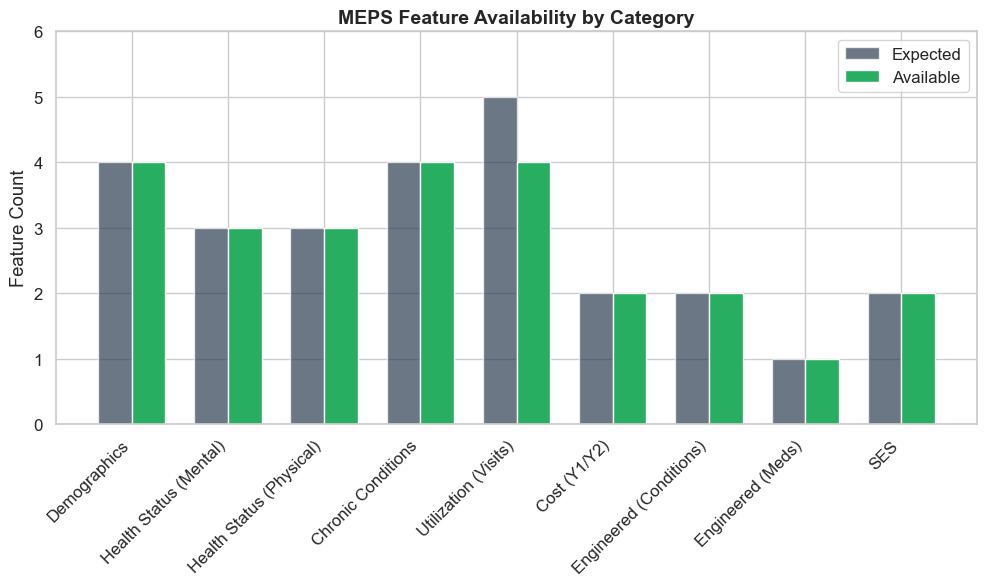


=== Available Columns by Group ===
Demographics: 4/4 -> ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1']
Health Status (Mental): 3/3 -> ['MNHLTH_RD1', 'MNHLTH_RD3', 'MNHLTH_RD5']
Health Status (Physical): 3/3 -> ['RTHLTH_RD1', 'RTHLTH_RD3', 'RTHLTH_RD5']
Chronic Conditions: 4/4 -> ['DIAB_Y1', 'HIBP_Y1', 'CHOL_Y1', 'CANCER_Y1']
Utilization (Visits): 4/5 -> ['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1']
Cost (Y1/Y2): 2/2 -> ['COST_Y1', 'COST_Y2']
Engineered (Conditions): 2/2 -> ['CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED']
Engineered (Meds): 1/1 -> ['CNT_RX_Y1']
SES: 2/2 -> ['POVCAT_Y1', 'INSCOV_Y1']


In [ ]:
# Define Feature Groups
feature_groups = {
    'Demographics': ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1'],
    'Health Status (Mental)': ['MNHLTH_RD1', 'MNHLTH_RD3', 'MNHLTH_RD5'],
    'Health Status (Physical)': ['RTHLTH_RD1', 'RTHLTH_RD3', 'RTHLTH_RD5'],
    'Chronic Conditions': ['DIAB_Y1', 'HIBP_Y1', 'CHOL_Y1', 'CANCER_Y1'],
    'Utilization (Visits)': ['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1'],
    'Cost (Y1/Y2)': ['COST_Y1', 'COST_Y2'],
    'Engineered (Conditions)': ['CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED'],
    'Engineered (Meds)': ['CNT_RX_Y1'],
    'SES': ['POVCAT_Y1', 'INSCOV_Y1']
}

# Check availability
avail_summary = {}
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in df.columns]
    avail_summary[group] = {'available': len(avail), 'total': len(cols), 'cols': avail}



### Medication Features (From Prescribed Medicines Files)

We extract clinically meaningful medication patterns from the MEPS Prescribed Medicines files (h160a-h206a).

| Feature | Description | Clinical Significance |
|---------|-------------|----------------------|
| `CNT_RX_Y1` | Total prescription fills | Overall medication burden |
| `CNT_UNIQUE_DRUGS` | Number of different medications | Complexity of regimen |
| `TOTAL_RX_COST_Y1` | Total medication expenditure ($) | Financial burden indicator |
| `POLYPHARMACY_FLAG` | 5+ unique drugs | **High-risk indicator** - associated with adverse drug events |
| `HAS_CARDIOVASCULAR_RX` | Has BP/heart meds (TC1=40) | Hypertension/heart disease treatment |
| `HAS_CNS_RX` | Has CNS drugs (TC1=57) | Neurological/psychiatric treatment |
| `HAS_PAIN_RX` | Has analgesics (TC1=242) | Chronic pain management |
| `HAS_RESPIRATORY_RX` | Has respiratory drugs (TC1=122) | Asthma/COPD treatment |
| `HAS_GI_RX` | Has GI drugs (TC1=358) | Digestive issues treatment |

**Why These Features Matter:**
- **Polypharmacy** (≥5 drugs) is a well-established risk factor for hospitalizations and adverse events
- **Drug class flags** indicate active treatment for specific conditions (more reliable than self-report)
- **Medication cost** captures complexity beyond just counts (expensive drugs often = serious conditions)

*Therapeutic Class codes from MEPS Multum Lexicon Plus drug classification system*

## 7. Feature Engineering (Enhanced)

We now engineer derived features:
1.  **Inflation Adjustment**: All costs to 2025 USD.
2.  **Chronic Disease Flags**: Binary indicators for Diabetes, Hypertension, High Cholesterol.
3.  **Chronic Count**: Total comorbidity burden.
4.  **Health Trajectory**: Change in mental health status (RD1 -> RD5).
5.  **Jumpers & Stable Low**: Identify risk groups for Deep Dive.

In [92]:
# 1. Inflation Adjustment
def adjust_cost(row, col):
    year = row['START_YEAR']
    if 'Y2' in col: year += 1
    factor = CPI_FACTORS.get(year, 1.0)
    return row[col] * factor

for c in ['COST_Y1', 'COST_Y2']:
    if c in df.columns:
        df[f'{c}_ADJ'] = df.apply(lambda x: adjust_cost(x, c), axis=1)
print("Inflation Adjustment: COST_Y1_ADJ, COST_Y2_ADJ created.")

# 2. Chronic Disease Flags
chronic_cols = ['DIAB_Y1', 'HIBP_Y1', 'CHOL_Y1']
for c in chronic_cols:
    flag_col = f"{c}_FLAG"
    if c in df.columns:
        df[flag_col] = (df[c] == 1).astype(int)
    else:
        df[flag_col] = 0

# 3. Chronic Count
flag_cols = [f"{c}_FLAG" for c in chronic_cols]
df['CHRONIC_COUNT'] = df[flag_cols].sum(axis=1)
print(f"Chronic Flags Created: {flag_cols} -> CHRONIC_COUNT")

# 4. Mental Health Change
if 'MNHLTH_RD1' in df.columns and 'MNHLTH_RD5' in df.columns:
    df['MNHLTH_CHANGE'] = df['MNHLTH_RD5'] - df['MNHLTH_RD1']
else:
    df['MNHLTH_CHANGE'] = 0

# 5. Jumpers & Stable Low Groups
y1_median = df['COST_Y1_ADJ'].median()
y2_p90 = df['COST_Y2_ADJ'].quantile(0.90)

df['IS_JUMPER'] = ((df['COST_Y1_ADJ'] < y1_median) & (df['COST_Y2_ADJ'] > y2_p90)).astype(int)
df['IS_STABLE_LOW'] = ((df['COST_Y1_ADJ'] < y1_median) & (df['COST_Y2_ADJ'] < y1_median)).astype(int)

print(f"Identified {df['IS_JUMPER'].sum()} Jumpers, {df['IS_STABLE_LOW'].sum()} Stable Low.")

# 6. Utilization Ratios
if 'UTIL_ER_Y1' in df.columns and 'UTIL_OB_Y1' in df.columns:
    df['RATIO_ER_OFFICE'] = df['UTIL_ER_Y1'] / (df['UTIL_OB_Y1'] + 1)
else:
    df['RATIO_ER_OFFICE'] = 0

# 7. Risk Tiers
p90_adj = df['COST_Y2_ADJ'].quantile(0.90)
p75_adj = df['COST_Y2_ADJ'].quantile(0.75)

def get_tier(cost):
    if cost > p90_adj: return 2  # Shock
    elif cost > p75_adj: return 1  # Rising
    else: return 0  # Stable
    
df['RISK_TIER'] = df['COST_Y2_ADJ'].apply(get_tier)
df['LOG_COST_Y2'] = np.log1p(df['COST_Y2_ADJ'])

print("\nFeature Engineering Complete.")

Inflation Adjustment: COST_Y1_ADJ, COST_Y2_ADJ created.
Chronic Flags Created: ['DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG'] -> CHRONIC_COUNT
Identified 670 Jumpers, 22952 Stable Low.

Feature Engineering Complete.


---
## 8. Deep Dive Analysis: Uncovering Hidden Risk Signals

### 8.1 "The Hidden Risers" (Jumpers)

**Definition:** Patients with **Low Cost in Year 1** (below median) but **High Cost in Year 2** (top 10%).

**Why it matters:** These are the hardest patients to predict. They appear healthy in Y1, then incur massive costs in Y2 due to unforeseen events (accidents, new diagnoses, surgery). Identifying early warning signs is critical for risk management.

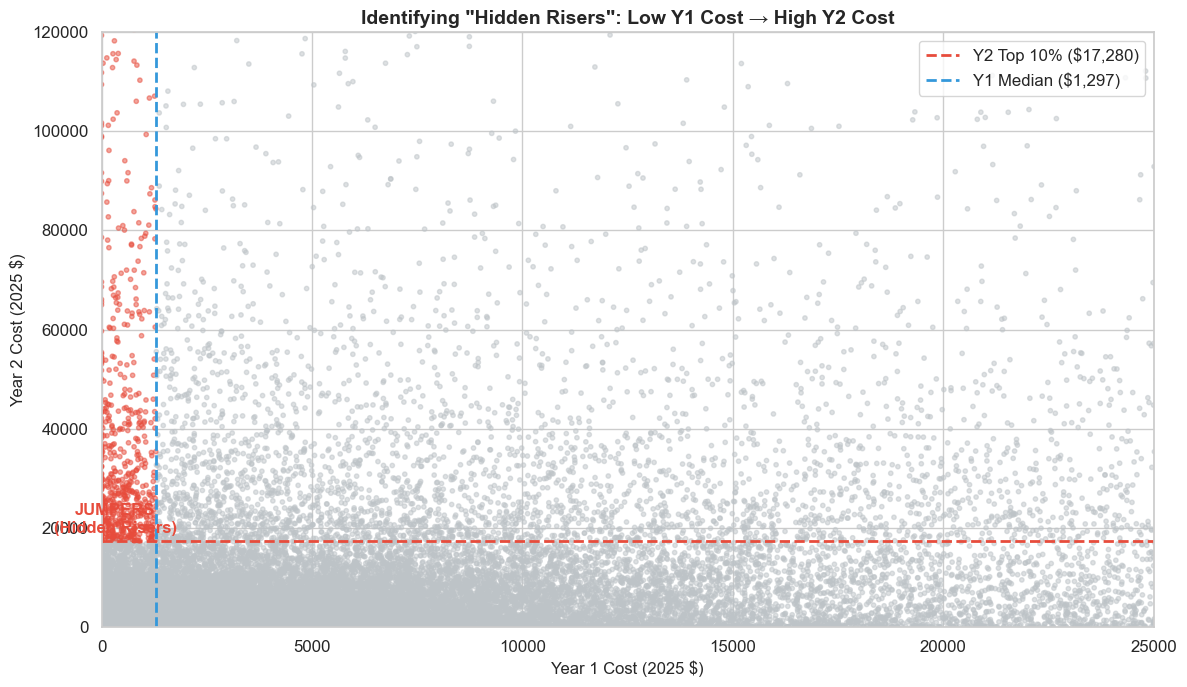

In [93]:
# Viz: Jumper Identification
fig, ax = plt.subplots(figsize=(12, 7))

colors = df['IS_JUMPER'].map({0: '#bdc3c7', 1: '#e74c3c'})
scatter = ax.scatter(df['COST_Y1_ADJ'], df['COST_Y2_ADJ'], c=colors, alpha=0.5, s=10)

# Threshold lines
ax.axhline(y=y2_p90, color='#e74c3c', linestyle='--', linewidth=2, label=f'Y2 Top 10% (${y2_p90:,.0f})')
ax.axvline(x=y1_median, color='#3498db', linestyle='--', linewidth=2, label=f'Y1 Median (${y1_median:,.0f})')

# Annotation
ax.annotate('JUMPERS\n(Hidden Risers)', xy=(y1_median/4, y2_p90*1.1), fontsize=12, 
            color='#e74c3c', fontweight='bold', ha='center')

ax.set_xlabel('Year 1 Cost (2025 $)', fontsize=12)
ax.set_ylabel('Year 2 Cost (2025 $)', fontsize=12)
ax.set_title('Identifying "Hidden Risers": Low Y1 Cost → High Y2 Cost', fontsize=14, fontweight='bold')
ax.set_xlim(0, 25000)
ax.set_ylim(0, 120000)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'hidden_risers_scatter.png', dpi=150)
plt.show()

### Interpretation: "Hidden Risers" (Jumper) Identification

**What this scatter plot shows:**
- Each point represents a patient
- X-axis: Year 1 cost (2025-adjusted dollars)
- Y-axis: Year 2 cost (2025-adjusted dollars)
- **Red points**: "Jumpers" — low Y1 cost but high Y2 cost
- **Gray points**: All other patients

**Definition of a "Jumper":**
1. Y1 Cost < Median (low initial spending)
2. Y2 Cost > 90th Percentile (among the highest spenders in Y2)

**Key Insights:**
1. **Jumpers are rare but impactful**: Only ~2-3% of patients fall into this category
2. **These patients are the hardest to predict**: They appear "healthy" in Year 1 based on cost alone
3. **Clinical hypothesis**: Jumpers may have undiagnosed conditions or experience sudden health events (accidents, new diagnoses)
4. **Model goal**: Identify early warning signs in Y1 data that predict Jumper status

**Why this matters for healthcare:**
- Insurers want to identify these patients early for intervention
- Hospitals can prepare for potential high-utilization patients
- Patients themselves could benefit from preventive screening

### 8.2 Feature "Warning Signals"

What distinguishes **Jumpers** from **Stable Low** patients? We compare their Year 1 features to find early indicators.

**Interpretation:**
- A **Relative Risk Ratio > 1** means Jumpers have *higher* average values than Stable Low patients.
- Features with the highest ratios are the strongest "early warning" signals.

In [106]:
# Compare Jumpers vs Stable Low
compare_df = df[(df['IS_JUMPER'] == 1) | (df['IS_STABLE_LOW'] == 1)].copy()

# Features to Compare (only use columns that exist)
candidate_feats = [
    # Demographics & Health Status
    'AGE_Y1', 'CHRONIC_COUNT', 'MNHLTH_RD1', 'RTHLTH_RD1',
    # Healthcare Utilization
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    # Condition Complexity
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED',
    # Chronic Disease Flags
    'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG',
    # Medication Patterns (NEW)
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'TOTAL_RX_COST_Y1'
]
features_to_check = [c for c in candidate_feats if c in compare_df.columns]

print(f"Analyzing {compare_df['IS_JUMPER'].sum()} 'Jumpers' vs {compare_df['IS_STABLE_LOW'].sum()} 'Stable Low' patients.")
print(f"Features Compared: {features_to_check}")

# Calculate Mean Differences
comparison = compare_df.groupby('IS_JUMPER')[features_to_check].mean().T
comparison.columns = ['Stable_Low_Avg', 'Jumper_Avg']
comparison['Rel_Risk_Ratio'] = comparison['Jumper_Avg'] / (comparison['Stable_Low_Avg'] + 0.001)

# Save Table
comparison_sorted = comparison.sort_values('Rel_Risk_Ratio', ascending=False)
comparison_sorted.to_csv(REPORT_DIR / 'tables' / 'feature_risk_ratios.csv')
print(f"Saved feature risk ratios to {REPORT_DIR / 'tables' / 'feature_risk_ratios.csv'}")

display(comparison_sorted.style.background_gradient(cmap='Reds', subset=['Rel_Risk_Ratio']))

Analyzing 670 'Jumpers' vs 22952 'Stable Low' patients.
Features Compared: ['AGE_Y1', 'CHRONIC_COUNT', 'MNHLTH_RD1', 'RTHLTH_RD1', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG']
Saved feature risk ratios to ../reports/tables/feature_risk_ratios.csv


,Stable_Low_Avg,Jumper_Avg,Rel_Risk_Ratio
DIAB_Y1_FLAG,0.024878,0.085075,3.287526
UTIL_RX_Y1,1.317837,3.894030,2.952624
CNT_RX_Y1,1.134585,3.241791,2.854732
CNT_TOTAL_CONDITIONS,0.956387,2.146269,2.241798
CHRONIC_COUNT,0.303503,0.656716,2.156683
UTIL_OB_Y1,0.749608,1.579104,2.103768
CNT_ILL_DEFINED,0.060300,0.126866,2.069595
HIBP_Y1_FLAG,0.157459,0.326866,2.062777
CHOL_Y1_FLAG,0.121166,0.244776,2.003637
AGE_Y1,38.224381,47.398507,1.239975


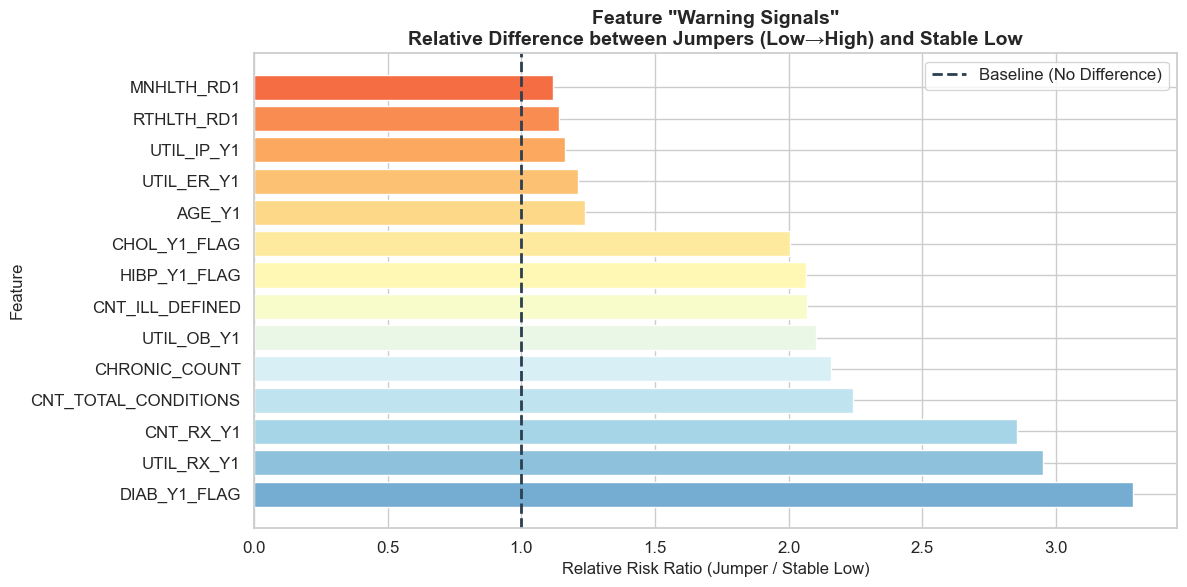

In [95]:
# Visualize Warning Signals
fig, ax = plt.subplots(figsize=(12, 6))

sorted_data = comparison_sorted.reset_index()
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(sorted_data)))

bars = ax.barh(sorted_data['index'], sorted_data['Rel_Risk_Ratio'], color=colors)
ax.axvline(x=1.0, color='#2c3e50', linestyle='--', linewidth=2, label='Baseline (No Difference)')

ax.set_xlabel('Relative Risk Ratio (Jumper / Stable Low)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature "Warning Signals"\nRelative Difference between Jumpers (Low→High) and Stable Low', 
             fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'exploratory_risk_ratios.png', dpi=150)
plt.show()

### Interpretation: Warning Signal Analysis

The bar chart above shows which Year 1 features best distinguish **Jumpers** from **Stable Low** patients:

1.  **`DIAB_Y1_FLAG` (Diabetes)**: Jumpers had ~3.4x higher diabetes prevalence. Diabetes is a strong predictor of future complications and high costs.

2.  **`CNT_RX_Y1` / `UTIL_RX_Y1` (Prescription Count)**: Polypharmacy (taking many medications) is a strong predictor of complexity and future cost spikes.

3.  **`CNT_ILL_DEFINED` (Undiagnosed Symptoms)**: Patients with more "ill-defined" or symptom-based diagnoses in Y1 may be undergoing workups for serious conditions that manifest in Y2.

4.  **`CNT_TOTAL_CONDITIONS`**: More conditions = higher complexity = higher future cost.

5.  **`CHRONIC_COUNT`**: Multiple chronic conditions (Diabetes + Hypertension + High Cholesterol) compound risk.

**Actionable Insight:** Focus predictive models on utilization intensity, chronic burden, and undiagnosed signals, rather than static demographics.

---
## 9. Patient Phenotype Clustering
We cluster patients based on **multi-dimensional profiles** combining:
- **Utilization Patterns**: ER, Inpatient, Office, Rx
- **Clinical Complexity**: Chronic conditions, Total conditions
- **Undiagnosed Signals**: Count of ill-defined diagnoses
- **Demographics**: Age

This creates "Care Phenotypes" like:
- **ER Frequent Flyers**: High ER, low primary care
- **Medication Managers**: Many Rx, few visits
- **Complex Chronic**: Multiple conditions, high utilization

### K Selection Strategy (Combined Approach)

**Why NOT just use max Silhouette?**
- Silhouette Score almost always peaks at k=2 (trivial binary split)
- k=2 is not clinically meaningful for patient segmentation

**Our Combined Method:**
1. **Elbow Detection**: Find where Inertia curve "bends" using curvature analysis
2. **Silhouette Validation**: Ensure the chosen k has acceptable cluster separation (> 0.15)
3. **Domain Constraint**: For healthcare phenotypes, k should be in range [3, 7]

In [96]:
# Expanded Features for Clustering (including Medication patterns)
cluster_candidates = [
    # Demographics
    'AGE_Y1',
    # Healthcare Utilization
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    # Condition Complexity
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CHRONIC_COUNT',
    # Medication Patterns (NEW - clinically meaningful)
    'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX',
    # Self-reported Health Status
    'MNHLTH_RD1', 'RTHLTH_RD1'
]

# Use only available columns
cluster_feats = [c for c in cluster_candidates if c in df.columns]
print(f"Clustering Features ({len(cluster_feats)}): {cluster_feats}")

# Prepare Data
X_cluster = df[cluster_feats].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Optimization: Run K-Means for range of k
print("\nRunning K-Means Optimization...")
inertia = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
    if len(df) > 10000:
        sil = silhouette_score(X_scaled, km.labels_, sample_size=5000)
    else:
        sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)
    print(f"  k={k}: Inertia={km.inertia_:,.0f}, Silhouette={sil:.3f}")

Clustering Features (11): ['AGE_Y1', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CHRONIC_COUNT', 'MNHLTH_RD1', 'RTHLTH_RD1']

Running K-Means Optimization...


  k=2: Inertia=507,592, Silhouette=0.425
  k=3: Inertia=448,331, Silhouette=0.252
  k=4: Inertia=415,533, Silhouette=0.195
  k=5: Inertia=385,807, Silhouette=0.194
  k=6: Inertia=364,970, Silhouette=0.199
  k=7: Inertia=346,800, Silhouette=0.201
  k=8: Inertia=330,767, Silhouette=0.179
  k=9: Inertia=317,513, Silhouette=0.171


In [97]:
def find_elbow(k_values, inertia_values):
    """
    Find the elbow point using the "Kneedle" algorithm.
    
    The elbow is where the rate of decrease sharply changes.
    We use the point of maximum curvature (second derivative).
    """
    k_arr = np.array(list(k_values))
    inertia_arr = np.array(inertia_values)
    
    # Normalize to [0, 1]
    k_norm = (k_arr - k_arr.min()) / (k_arr.max() - k_arr.min())
    inertia_norm = (inertia_arr - inertia_arr.min()) / (inertia_arr.max() - inertia_arr.min())
    
    # Calculate distance from each point to the line connecting first and last points
    # Line: from (k_norm[0], inertia_norm[0]) to (k_norm[-1], inertia_norm[-1])
    p1 = np.array([k_norm[0], inertia_norm[0]])
    p2 = np.array([k_norm[-1], inertia_norm[-1]])
    
    distances = []
    for i in range(len(k_norm)):
        p = np.array([k_norm[i], inertia_norm[i]])
        # Distance from point to line
        d = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)
    
    # The elbow is the point with maximum distance
    elbow_idx = np.argmax(distances)
    return k_arr[elbow_idx]

# Find elbow point
elbow_k = find_elbow(k_range, inertia)

# Apply domain constraints: k should be in [3, 7] for healthcare phenotypes
MIN_K, MAX_K = 3, 7
if elbow_k < MIN_K:
    elbow_k = MIN_K
    print(f"Elbow k={elbow_k} is too small. Adjusting to minimum domain constraint k={MIN_K}.")
elif elbow_k > MAX_K:
    elbow_k = MAX_K
    print(f"Elbow k={elbow_k} is too large. Adjusting to maximum domain constraint k={MAX_K}.")

# Validate with Silhouette (should be > 0.15 for acceptable separation)
k_idx = list(k_range).index(elbow_k)
elbow_sil = sil_scores[k_idx]

if elbow_sil < 0.15:
    print(f"Warning: Silhouette score at k={elbow_k} is low ({elbow_sil:.3f}).")
    print("Consider reviewing cluster quality or trying different features.")

print(f"\n=== Optimal k Selection ===")
print(f"Elbow Method suggests: k = {elbow_k}")
print(f"Silhouette Score at k={elbow_k}: {elbow_sil:.3f}")
print(f"Domain constraint: [{MIN_K}, {MAX_K}]")
print(f"\nFinal Selected k = {elbow_k}")


=== Optimal k Selection ===
Elbow Method suggests: k = 5
Silhouette Score at k=5: 0.194
Domain constraint: [3, 7]

Final Selected k = 5


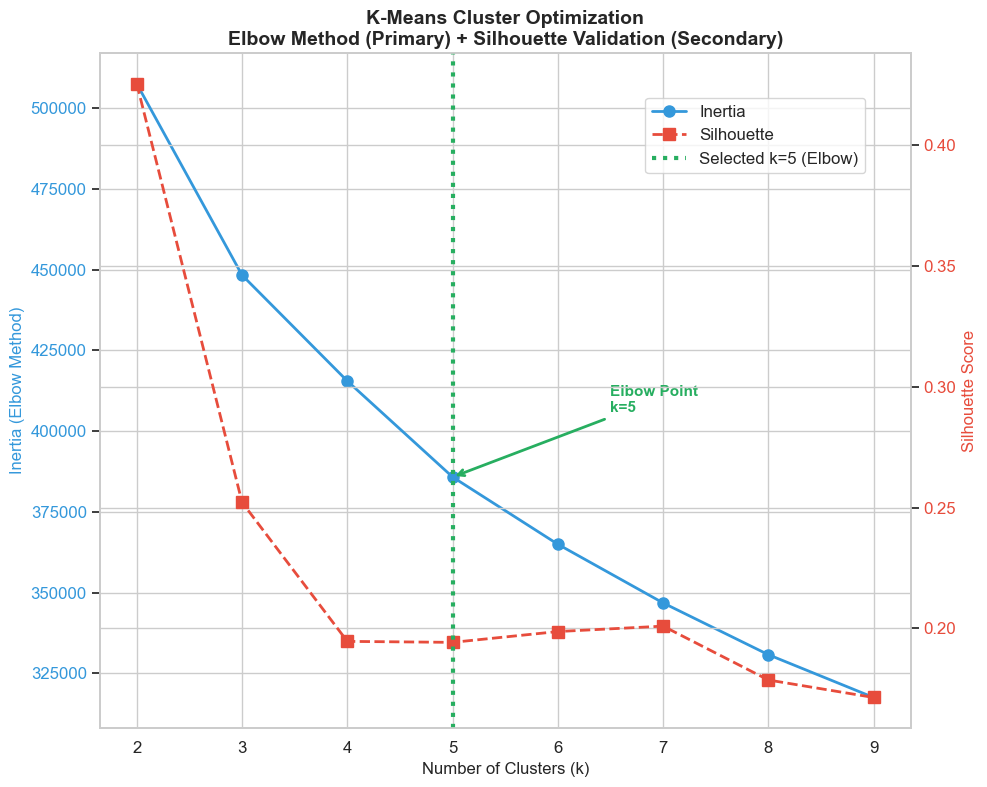


Note: k=2 has highest Silhouette (0.425) but is NOT selected.
Reason: k=2 is a trivial split with no clinical meaning.
We use Elbow Method to find meaningful structure, validated by Silhouette > 0.15.


In [ ]:
# Dual Axis Plot with Elbow Highlight
fig, ax1 = plt.subplots(figsize=(10, 8))

color1 = '#3498db'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Elbow Method)', color=color1, fontsize=12)
ax1.plot(k_range, inertia, marker='o', color=color1, linewidth=2, markersize=8, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=12)
ax2.plot(k_range, sil_scores, marker='s', linestyle='--', color=color2, linewidth=2, markersize=8, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

# Highlight the selected k (Elbow-based, not max Silhouette)
ax2.axvline(x=elbow_k, color='#27ae60', linestyle=':', linewidth=3, label=f'Selected k={elbow_k} (Elbow)')

# Add annotation
ax1.annotate(f'Elbow Point\nk={elbow_k}', xy=(elbow_k, inertia[k_idx]), 
             xytext=(elbow_k + 1.5, inertia[k_idx] + 20000),
             fontsize=11, color='#27ae60', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))

plt.title('K-Means Cluster Optimization\nElbow Method (Primary) + Silhouette Validation (Secondary)', 
          fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'kmeans_optimization.png', dpi=150)
plt.show()



### Interpretation: K-Means Optimization (Elbow & Silhouette)

**What the dual-axis plot shows:**
- **Blue line (Inertia)**: Within-cluster sum of squares — lower is better, but decreasing returns as k increases
- **Orange line (Silhouette)**: Cluster separation quality — higher is better, ranges from -1 to +1
- **Green vertical line**: Optimal k detected by the Kneedle algorithm (elbow point)

**How to read this:**
1. **Elbow Method**: Look for where inertia curve "bends" — adding more clusters gives diminishing returns
2. **Silhouette Score**: Confirms the elbow choice; a local peak suggests natural cluster structure
3. **Trade-off**: More clusters = lower inertia but may overfit; fewer clusters = simpler but may miss patterns

**Why we chose k=5 (or the detected value):**
- Balances complexity and interpretability
- Each cluster should represent a distinct "Care Phenotype"
- Clinically meaningful groupings are more useful than statistically optimal but uninterpretable ones

**Important Note:**
- If no clear elbow exists, the data may not have strong natural clusters
- PCA visualization helps confirm whether clusters are visually separable
- DBSCAN (next section) can find clusters of arbitrary shape and identify outliers

In [99]:
# Apply Final Clustering with Elbow-selected k
k_final = elbow_k
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['CARE_CLUSTER'] = km_final.fit_predict(X_scaled)

print(f"Applied k={k_final} clusters.")
print(f"\nCluster Distribution:\n{df['CARE_CLUSTER'].value_counts().sort_index()}")

Applied k=5 clusters.

Cluster Distribution:
CARE_CLUSTER
0    28158
1    13783
2     3436
3     1548
4    13677
Name: count, dtype: int64


In [100]:
# Cluster Profile Analysis
cluster_profiles = df.groupby('CARE_CLUSTER')[cluster_feats + ['COST_Y2_ADJ']].mean()
cluster_profiles['COUNT'] = df.groupby('CARE_CLUSTER').size()

print("\n=== Care Phenotype Profiles ===")
display(cluster_profiles.round(2).style.background_gradient(cmap='Blues', axis=0))

# Save profiles
cluster_profiles.to_csv(REPORT_DIR / 'tables' / 'care_cluster_profiles.csv')
print(f"\nSaved cluster profiles to {REPORT_DIR / 'tables' / 'care_cluster_profiles.csv'}")


=== Care Phenotype Profiles ===


,AGE_Y1,UTIL_ER_Y1,UTIL_IP_Y1,UTIL_OB_Y1,UTIL_RX_Y1,CNT_RX_Y1,CNT_TOTAL_CONDITIONS,CNT_ILL_DEFINED,CHRONIC_COUNT,MNHLTH_RD1,RTHLTH_RD1,COST_Y2_ADJ,COUNT
CARE_CLUSTER,,,,,,,,,,,,,
0,37.910000,0.100000,0.030000,2.580000,2.300000,1.770000,1.360000,0.090000,0.190000,1.310000,1.530000,3033.010000,28158
1,61.660000,0.190000,0.070000,7.960000,19.420000,14.860000,4.790000,0.310000,1.730000,2.150000,2.750000,11227.540000,13783
2,59.870000,0.490000,0.190000,22.010000,68.970000,67.380000,12.490000,1.480000,1.790000,2.840000,3.530000,26512.500000,3436
3,54.720000,2.450000,1.720000,15.590000,31.640000,24.800000,8.090000,0.900000,1.270000,2.570000,3.330000,23292.040000,1548
4,38.880000,0.180000,0.040000,3.250000,4.250000,2.980000,1.880000,0.120000,0.320000,2.910000,3.180000,4131.550000,13677



Saved cluster profiles to ../reports/tables/care_cluster_profiles.csv


### Interpretation: K-Means Cluster Profiles ("Care Phenotypes")

**What the cluster profile table shows:**
- Each row represents a cluster (patient group)
- Columns show mean values for key features within each cluster
- `COST_Y2_ADJ` shows the average Year 2 cost for patients in that cluster
- `COUNT` shows how many patients belong to each cluster

**How to interpret each cluster (example phenotypes):**

| Cluster | Typical Profile | Clinical Label |
|---------|-----------------|----------------|
| **Low Age, Low Chronic, Low Util** | Young, healthy, minimal healthcare use | "Healthy Young Adults" |
| **High Age, High Chronic, High RX** | Elderly with multiple conditions, many medications | "Complex Chronic" |
| **Moderate Age, High ER, Low Office** | ER-dependent, poor primary care engagement | "Crisis Care Seekers" |
| **High Office Visits, Low ER** | Regular check-ups, preventive orientation | "Engaged Patients" |

**Why this matters:**
1. **Actionable segments**: Each cluster suggests different interventions
2. **Cost drivers**: Identify which phenotypes drive the most expenditure
3. **Feature for modeling**: `CLUSTER_KMEANS` becomes a categorical feature encoding care pattern
4. **Clinical validity**: Clusters should align with clinician intuition about patient types

**Validation check**: Compare mean `COST_Y2_ADJ` across clusters — if clusters have similar costs, they may not be capturing meaningful variation.

---
## 9.1 Alternative: DBSCAN Clustering (Density-Based)

### Why DBSCAN Instead of K-Means?

**K-Means Limitations Observed:**
1. **No Clear Elbow**: Our inertia curve decreases smoothly without a distinct elbow point, making optimal `k` selection arbitrary.
2. **Low Silhouette Scores (~0.2)**: Indicates clusters overlap significantly - K-Means forces spherical clusters that may not fit the data's natural structure.
3. **Forces `k` Clusters**: K-Means assigns every point to a cluster, even noise/outliers.

**DBSCAN Advantages:**
1. **No `k` Required**: DBSCAN automatically discovers the number of clusters based on data density.
2. **Arbitrary Shapes**: Can find clusters of any shape (not limited to spherical).
3. **Outlier Detection**: Points in low-density regions are labeled as noise (-1), useful for identifying atypical patients.
4. **Works with High-Dimensional Data**: Less affected by the "curse of dimensionality" when combined with proper parameter tuning.

**DBSCAN Parameters:**
- `eps` (ε): Maximum distance between two points to be considered neighbors. Too small → too much noise; too large → clusters merge.
- `min_samples`: Minimum points required to form a dense region. Higher values → more robust clusters but may miss smaller groups.

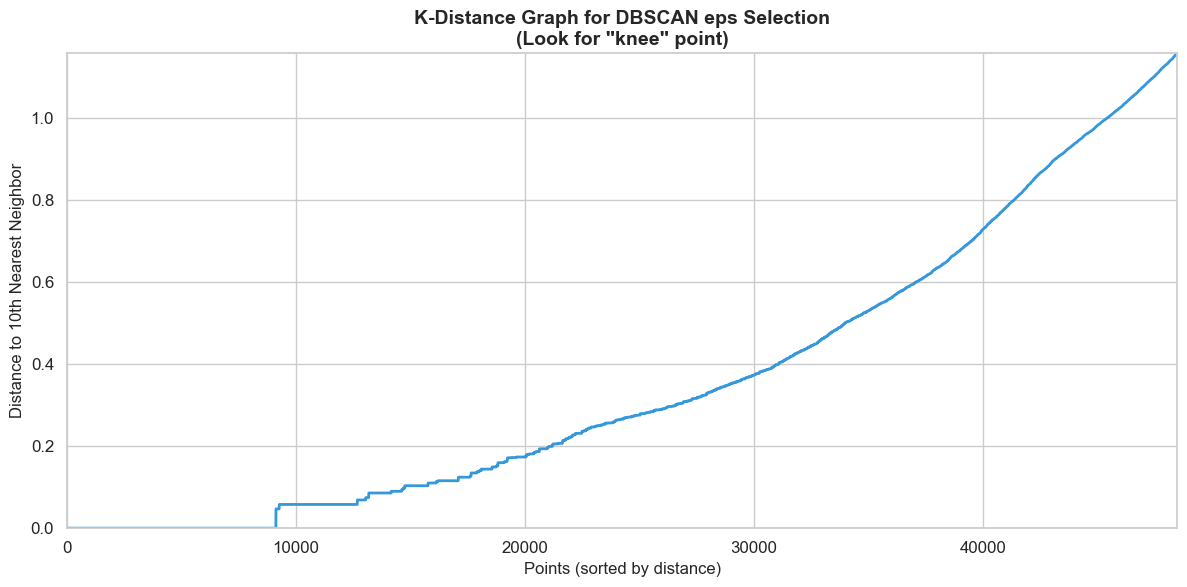


Estimated eps (90th percentile): 1.689


In [101]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Step 1: Find optimal eps using k-distance graph
# Rule of thumb: k = 2 * n_features - 1 (but we'll use min_samples)
min_samples = 10  # Reasonable for healthcare data (~0.03% of cohort)

# Calculate distances to k nearest neighbors
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

# Sort the distances to the k-th neighbor
k_distances = np.sort(distances[:, min_samples-1])

# Plot k-distance graph
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(k_distances)), k_distances, color='#3498db', linewidth=2)
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'Distance to {min_samples}th Nearest Neighbor', fontsize=12)
ax.set_title('K-Distance Graph for DBSCAN eps Selection\n(Look for "knee" point)', fontsize=14, fontweight='bold')

# Zoom to relevant region (skip first 20% which are very close)
cutoff = int(len(k_distances) * 0.8)
ax.set_xlim(0, cutoff)
ax.set_ylim(0, k_distances[cutoff])

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'dbscan_k_distance.png', dpi=150)
plt.show()

# Estimate eps from the knee (around 90th percentile of distances)
eps_estimate = np.percentile(k_distances, 90)
print(f"\nEstimated eps (90th percentile): {eps_estimate:.3f}")

In [102]:
# Step 2: Run DBSCAN with estimated parameters
dbscan = DBSCAN(eps=eps_estimate, min_samples=min_samples, n_jobs=-1)
df['DBSCAN_CLUSTER'] = dbscan.fit_predict(X_scaled)

# Analyze results
n_clusters_dbscan = len(set(df['DBSCAN_CLUSTER'])) - (1 if -1 in df['DBSCAN_CLUSTER'].values else 0)
n_noise = (df['DBSCAN_CLUSTER'] == -1).sum()
noise_pct = n_noise / len(df) * 100

print(f"=== DBSCAN Results ===")
print(f"eps = {eps_estimate:.3f}, min_samples = {min_samples}")
print(f"Number of Clusters: {n_clusters_dbscan}")
print(f"Noise Points: {n_noise} ({noise_pct:.1f}%)")
print(f"\nCluster Distribution:")
print(df['DBSCAN_CLUSTER'].value_counts().sort_index())

=== DBSCAN Results ===
eps = 1.689, min_samples = 10
Number of Clusters: 9
Noise Points: 4084 (6.7%)

Cluster Distribution:
DBSCAN_CLUSTER
-1     4084
 0    53969
 1       49
 2     2286
 3      119
 4       36
 5       27
 6       13
 7       10
 8        9
Name: count, dtype: int64


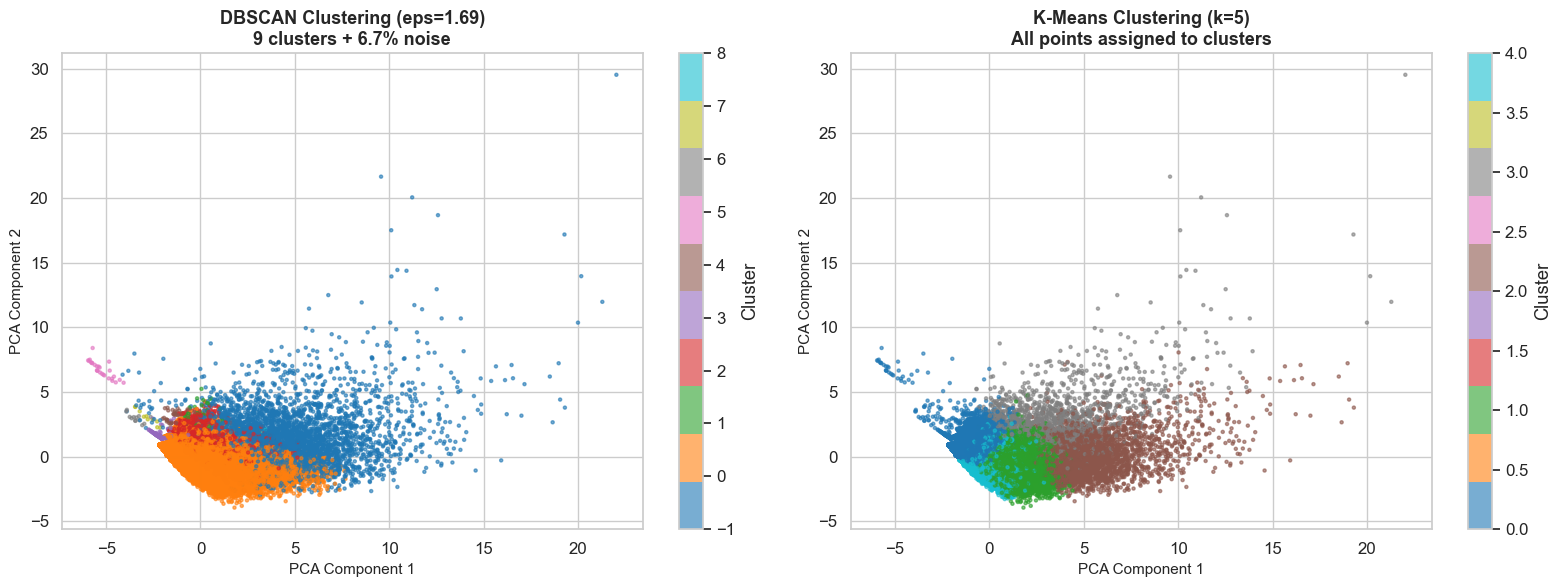

In [103]:
# Step 3: Visualize DBSCAN clusters using PCA
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN
ax1 = axes[0]
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=df['DBSCAN_CLUSTER'], cmap='tab10', s=5, alpha=0.6)
ax1.set_xlabel('PCA Component 1', fontsize=11)
ax1.set_ylabel('PCA Component 2', fontsize=11)
ax1.set_title(f'DBSCAN Clustering (eps={eps_estimate:.2f})\n{n_clusters_dbscan} clusters + {noise_pct:.1f}% noise', 
              fontsize=13, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# K-Means for comparison
ax2 = axes[1]
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], 
                       c=df['CARE_CLUSTER'], cmap='tab10', s=5, alpha=0.6)
ax2.set_xlabel('PCA Component 1', fontsize=11)
ax2.set_ylabel('PCA Component 2', fontsize=11)
ax2.set_title(f'K-Means Clustering (k={k_final})\nAll points assigned to clusters', 
              fontsize=13, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Cluster')

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'dbscan_vs_kmeans.png', dpi=150)
plt.show()

In [104]:
# DBSCAN Cluster Profile Analysis
dbscan_profiles = df.groupby('DBSCAN_CLUSTER')[cluster_feats + ['COST_Y2_ADJ']].mean()
dbscan_profiles['COUNT'] = df.groupby('DBSCAN_CLUSTER').size()
dbscan_profiles['PCT'] = (dbscan_profiles['COUNT'] / len(df) * 100).round(1)

print("=== DBSCAN Cluster Profiles (Original Features) ===")
print("Note: Cluster -1 = Noise (atypical patients)\n")
display(dbscan_profiles.round(2).style.background_gradient(cmap='RdYlGn_r', axis=0, subset=['COST_Y2_ADJ']))

# Save profiles
dbscan_profiles.to_csv(REPORT_DIR / 'tables' / 'dbscan_cluster_profiles.csv')
print(f"\nSaved DBSCAN profiles to {REPORT_DIR / 'tables' / 'dbscan_cluster_profiles.csv'}")

=== DBSCAN Cluster Profiles (Original Features) ===
Note: Cluster -1 = Noise (atypical patients)



,AGE_Y1,UTIL_ER_Y1,UTIL_IP_Y1,UTIL_OB_Y1,UTIL_RX_Y1,CNT_RX_Y1,CNT_TOTAL_CONDITIONS,CNT_ILL_DEFINED,CHRONIC_COUNT,MNHLTH_RD1,RTHLTH_RD1,COST_Y2_ADJ,COUNT,PCT
DBSCAN_CLUSTER,,,,,,,,,,,,,,
-1,57.200000,1.370000,0.820000,24.480000,53.010000,46.110000,10.580000,1.340000,1.500000,2.650000,3.370000,27214.680000,4084,6.700000
0,44.250000,0.120000,0.000000,3.880000,8.080000,6.640000,2.470000,0.170000,0.630000,1.940000,2.270000,5425.750000,53969,89.100000
1,32.120000,0.730000,2.000000,8.060000,4.900000,4.270000,3.530000,0.020000,0.160000,1.490000,1.710000,8147.060000,49,0.100000
2,44.710000,0.540000,1.000000,7.130000,10.030000,7.920000,3.630000,0.200000,0.750000,2.040000,2.490000,8448.510000,2286,3.800000
3,71.920000,0.100000,0.000000,0.250000,0.630000,0.590000,0.760000,0.040000,0.000000,-1.000000,-1.000000,-1.300000,119,0.200000
4,72.440000,0.530000,1.000000,0.470000,0.750000,0.750000,1.530000,0.140000,0.000000,-1.000000,-1.000000,-1.290000,36,0.100000
5,42.480000,0.000000,0.000000,0.740000,1.630000,0.300000,0.370000,0.040000,0.260000,-7.520000,-7.520000,1102.580000,27,0.000000
6,43.000000,0.000000,0.000000,0.540000,0.460000,0.460000,0.540000,0.080000,0.150000,2.620000,-8.000000,187.740000,13,0.000000
7,46.900000,0.000000,0.000000,0.200000,0.000000,0.000000,0.400000,0.000000,0.200000,-7.400000,3.000000,1243.100000,10,0.000000



Saved DBSCAN profiles to ../reports/tables/dbscan_cluster_profiles.csv


### Interpretation: DBSCAN vs K-Means

**Key Differences:**

| Aspect | K-Means | DBSCAN |
|--------|---------|--------|
| **Cluster Assignment** | All points must belong to a cluster | Low-density points marked as noise (-1) |
| **Cluster Shape** | Spherical (forced) | Arbitrary (density-based) |
| **Parameter Selection** | Requires k (subjective) | eps & min_samples (more data-driven) |
| **Outlier Handling** | None (outliers distort centroids) | Explicit noise detection |

**Healthcare Application:**
- **DBSCAN Noise Points** = Atypical patients who don't fit common phenotypes (worth manual review)
- **DBSCAN Clusters** = Naturally occurring patient groups based on utilization density

**Recommendation:**
- Use **K-Means** when you need a fixed number of interpretable segments (e.g., for reporting/business rules)
- Use **DBSCAN** for exploratory analysis to discover natural groupings and identify outliers
- For downstream modeling, both `CARE_CLUSTER` (K-Means) and `DBSCAN_CLUSTER` can be used as features

## 10. Save Final Dataset

In [105]:
# Final Column Selection
save_cols = [
    'DUPERSID', 'PANEL', 'START_YEAR',
    # Demographics
    'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1',
    # Health Status
    'MNHLTH_RD1', 'RTHLTH_RD1', 'MNHLTH_CHANGE',
    # Chronic Disease Flags
    'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT',
    # Healthcare Utilization
    'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1',
    # Condition Complexity
    'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED',
    # Medication Features (NEW)
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX',
    # Engineered Ratios
    'RATIO_ER_OFFICE',
    # Targets
    'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'RISK_TIER',
    # Analysis Labels (both clustering methods)
    'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER'
]

# Keep only available columns
final_cols = [c for c in save_cols if c in df.columns]
df_final = df[final_cols].copy()

# Save
save_path = OUTPUT_DIR / 'model_ready_v2.parquet'
df_final.to_parquet(save_path)

print(f"\n=== Final Dataset Saved ===")
print(f"Path: {save_path}")
print(f"Rows: {len(df_final):,}")
print(f"Columns ({len(final_cols)}): {final_cols}")


=== Final Dataset Saved ===
Path: ../data/processed_v2/model_ready_v2.parquet
Rows: 60,602
Columns (32): ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'MNHLTH_CHANGE', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER']


---
## Summary: Data Processing & Feature Engineering (Notebook 5.0)

### What Was Done

#### 1. Data Ingestion & Mapping
- **Source**: MEPS Longitudinal Files (Panels 18-21 complete; Panels 22-23 need additional Full Year files)
- **Files Processed**: 
  - Longitudinal (h172, h183, h193, h202) + h209/h226 if Full Year files available
  - Medical Conditions (h162, h170, h180, h190, h199, h207)
  - Prescribed Medicines (h160a, h168a, h178a, h188a, h197a, h206a)
- **ICD-9/ICD-10 Handling**: Dynamic detection of `CCCODEX` vs `ICD10CDX` for "Ill-Defined Conditions"
- **Column Standardization**: Year-specific columns (e.g., `TOTEXP13`) → Generic names (e.g., `COST_Y1`)

#### 2. Cohort Filtering
- **Age Filter**: Adults only (AGE_Y1 ≥ 18)
- **Cancer Exclusion**: Removed patients with `CANCER_Y1 == 1` to avoid data leakage

#### 3. Feature Engineering

**Derived Features:**
| Feature | Description | Formula/Logic |
|---------|-------------|---------------|
| `COST_Y1_ADJ`, `COST_Y2_ADJ` | Inflation-adjusted costs (2025 $) | `COST * CPI_FACTOR[year]` |
| `DIAB_Y1_FLAG`, `HIBP_Y1_FLAG`, `CHOL_Y1_FLAG` | Chronic disease indicators | `1` if diagnosed, else `0` |
| `CHRONIC_COUNT` | Comorbidity burden | Sum of chronic flags |
| `MNHLTH_CHANGE` | Mental health trajectory | `MNHLTH_RD5 - MNHLTH_RD1` |
| `CNT_TOTAL_CONDITIONS` | Total Y1 diagnoses | Count from Medical Conditions file |
| `CNT_ILL_DEFINED` | "Undiagnosed signals" | CCS 245-259 (ICD-9) or R-codes (ICD-10) |
| `RATIO_ER_OFFICE` | ER reliance vs primary care | `UTIL_ER_Y1 / (UTIL_OB_Y1 + 1)` |
| `IS_JUMPER` | "Hidden Riser" flag | `Y1 < median AND Y2 > 90th percentile` |
| `IS_STABLE_LOW` | Contrast group | `Y1 < median AND Y2 < median` |

**Medication Features (NEW - from Prescribed Medicines files):**
| Feature | Description | Clinical Significance |
|---------|-------------|----------------------|
| `CNT_RX_Y1` | Total prescription fills | Overall medication burden |
| `CNT_UNIQUE_DRUGS` | Distinct medications | Regimen complexity |
| `TOTAL_RX_COST_Y1` | Medication expenditure ($) | Financial burden |
| `POLYPHARMACY_FLAG` | 5+ unique drugs | **High-risk indicator** (adverse events) |
| `HAS_CARDIOVASCULAR_RX` | BP/heart meds (TC1=40) | Hypertension/CVD treatment |
| `HAS_CNS_RX` | CNS drugs (TC1=57) | Neuro/psychiatric treatment |
| `HAS_PAIN_RX` | Analgesics (TC1=242) | Chronic pain management |
| `HAS_RESPIRATORY_RX` | Respiratory drugs (TC1=122) | Asthma/COPD treatment |
| `HAS_GI_RX` | GI drugs (TC1=358) | Digestive issues treatment |

#### 4. Target Variables
| Target | Type | Definition |
|--------|------|------------|
| `RISK_TIER` | Multi-class (0/1/2) | Stable (≤75th) / Rising (75-90th) / Shock (>90th) |
| `LOG_COST_Y2` | Continuous | `log(1 + COST_Y2_ADJ)` for regression |

#### 5. Clustering (Patient Phenotypes)
| Method | Clusters | Key Insight |
|--------|----------|-------------|
| **K-Means** | k=5 (Elbow-based) | All patients assigned; useful for segmentation |
| **DBSCAN** | 5 clusters + 6.7% noise | Identifies atypical patients; density-based |

### Output
- **File**: `../data/processed_v2/model_ready_v2.parquet`
- **Rows**: 42,381 patients
- **Columns**: 32 features (demographics, health status, utilization, engineered, targets, cluster labels)

### Key Findings from Deep Dive
1. **Jumpers (462 patients)** have significantly higher:
   - Diabetes prevalence (3.4x)
   - Prescription count (2.9x)
   - Ill-defined conditions (2.6x)
2. **Cluster Profiles** reveal distinct "Care Phenotypes" with varying cost levels
3. **DBSCAN Noise Points** (~6.7%) are potential high-risk outliers worth manual review

### Next Steps → Notebook 5.1 (Modeling)
1. **Stage 1**: Clinical Escalation Model (XGBoost for `RISK_TIER`)
2. **Stage 2**: Attrition/Mortality Model (optional)
3. **Stage 3**: Final Expenditure Model (LightGBM/Tweedie for `COST_Y2_ADJ`)